In [16]:
#load libraries
import pandas as pd                                                                                                                                                              
import matplotlib.pyplot as plt                                                                                                                                                  
import numpy as np     

In [17]:
#Pull data from Invisible Intitute's Public GitHub
URL = ("https://media.githubusercontent.com/media/invinst/chicago-police-data/"
        "master/data/unified_data/complaints/complaints-accused.csv")                                                                                                             
accused = pd.read_csv(URL, usecols=["UID", "cr_id", "disciplined"])
accused = accused.dropna(subset=["UID"])                                                                                                                                                 
accused["disciplined"] = accused["disciplined"].astype(str).str.lower().map(                                                                                                           
    {"true": 1, "false": 0}                                                                                                                                                      
).fillna(0)   

/var/folders/xq/rpzvqdzj38z4gwgc0tpbm37r0000gn/T/ipykernel_13629/1430716114.py:4: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  accused = pd.read_csv(URL, usecols=["UID", "cr_id", "disciplined"])


In [18]:
#combine all officers with more than one complaint into one row per officer, counting their complaints and calculating their discipline rate.                                                                                                                                                                            
                                                                                                  
per_officer = accused.groupby("UID").agg(                                                                                                                                            
    n_complaints=("cr_id", "nunique"),       
    disc_rate=("disciplined", "mean"),                                                                                                                                           
).reset_index()                                                                                                                                                                
                                                                                                                                                                                
# bin the data                                                                                                    
edges  = [0, 5, 10, 20, 30, 50, 100, np.inf] 
labels = ["1-5", "6-10", "11-20", "21-30", "31-50", "51-100", "100+"]                                                                                                            
per_officer["band"] = pd.cut(per_officer["n_complaints"],                                                                                                                      
                            bins=edges, labels=labels, right=True)                                                                                                              
                                                                                                                                                                                
bands_df = (per_officer.groupby("band", observed=True)                                                                                                                           
            .agg(n_officers=("UID", "count"),                                                                                                                                  
                total_complaints=("n_complaints", "sum"),                                                                                                                       
                avg_disciplined=("disc_rate", "mean"))                                                                                                                        
            .reindex(labels)                                                                                                                                                     
            .reset_index())
bands_df["avg_disciplined"] = (bands_df["avg_disciplined"] * 100).round(1)                                                                                                       
                                                                                                                                                                                
print(bands_df)  # sanity check against complaint_bands.csv

     band  n_officers  total_complaints  avg_disciplined
0     1-5       12444             31561             12.7
1    6-10        5639             43791              9.5
2   11-20        5173             75853              8.2
3   21-30        1931             47811              7.3
4   31-50        1134             42928              6.6
5  51-100         311             20032              6.4
6    100+          11              1339              4.3


In [19]:
bands = bands_df["band"].tolist()
n_officers = bands_df["n_officers"].to_numpy()
totals = bands_df["total_complaints"].to_numpy()
disc = bands_df["avg_disciplined"].to_numpy()
total_off = n_officers.sum()

# plot the same as on the site
fig, (ax_top, ax_bot) = plt.subplots(
    2, 1, figsize=(11, 7),
    gridspec_kw={"height_ratios": [1, 3], "hspace": 0.5},
)

# Top panel (stacked bar for number of complaints)
left = 0
shades = np.linspace(0.55, 1.0, len(bands))
centers = []
for i, (band, n) in enumerate(zip(bands, n_officers)):
    color = "#8b0000" if i == len(bands) - 1 else (0, 0, 0, shades[i])
    ax_top.barh(0, n, left=left, height=0.6, color=color)
    cx = left + n / 2
    centers.append(cx)
    if n / total_off > 0.05:  # wide segments get inline labels
        ax_top.text(cx, 0, f"{band}\n{n:,}",
                    ha="center", va="center", color="white",
                    fontsize=9, family="monospace")
    left += n

# Raised leader-line callouts for the three narrowest bands
callouts = [(4, 1.4), (5, 2.2), (6, 3.0)]   # (band index, label y)
for idx, y_label in callouts:
    band = bands[idx]
    n = n_officers[idx]
    cx = centers[idx]
    col = "#8b0000" if idx == len(bands) - 1 else "black"
    ax_top.annotate(f"{band}: {n:,}",
                    xy=(cx, 0.3),
                    xytext=(cx, y_label),
                    ha="center", color=col, fontsize=9, family="monospace",
                    arrowprops=dict(arrowstyle="-", color=col, lw=0.7))

ax_top.set_xlim(0, total_off)
ax_top.set_ylim(-1, 3.8)
ax_top.axis("off")

# Bottom panel: discipline-rate ramp
x = np.arange(len(bands))
sizes = (np.sqrt(totals) / np.sqrt(totals.max()) * 900) + 40
colors = ["black"] * (len(bands) - 1) + ["#8b0000"]

#graph controls
ax_bot.plot(x, disc, color="black", lw=1.2, zorder=1)
ax_bot.scatter(x, disc, s=sizes, c=colors, zorder=2)

ax_bot.text(x[0],  disc[0]  + 1.2, f"{disc[0]}%",
            ha="center", fontsize=14, fontweight="bold")
ax_bot.text(x[-1], disc[-1] + 1.2, f"{disc[-1]}%",
            ha="center", fontsize=14, fontweight="bold", color="#8b0000")

ax_bot.set_xticks(x)
ax_bot.set_xticklabels(bands, family="monospace")
ax_bot.set_ylim(0, 15)
ax_bot.set_yticks([0, 5, 10, 15])
ax_bot.set_yticklabels(["0%", "5%", "10%", "15%"], family="monospace")
ax_bot.set_ylabel("AVG DISCIPLINE RATE", family="monospace", fontsize=9)
ax_bot.text(0, -2.2, "\u2190 fewer complaints", style="italic", fontsize=9)
ax_bot.text(len(bands) - 1, -2.2, "more complaints \u2192",
            style="italic", fontsize=9, ha="right")

for spine in ("top", "right"):
    ax_bot.spines[spine].set_visible(False)

plt.suptitle("The Accountability Inversion", fontsize=16, fontweight="bold", y=0.98)
plt.savefig("inversion.png", dpi=150, bbox_inches="tight");

plt.savefig("my_graph.png", dpi=300, bbox_inches="tight")
plt.close()

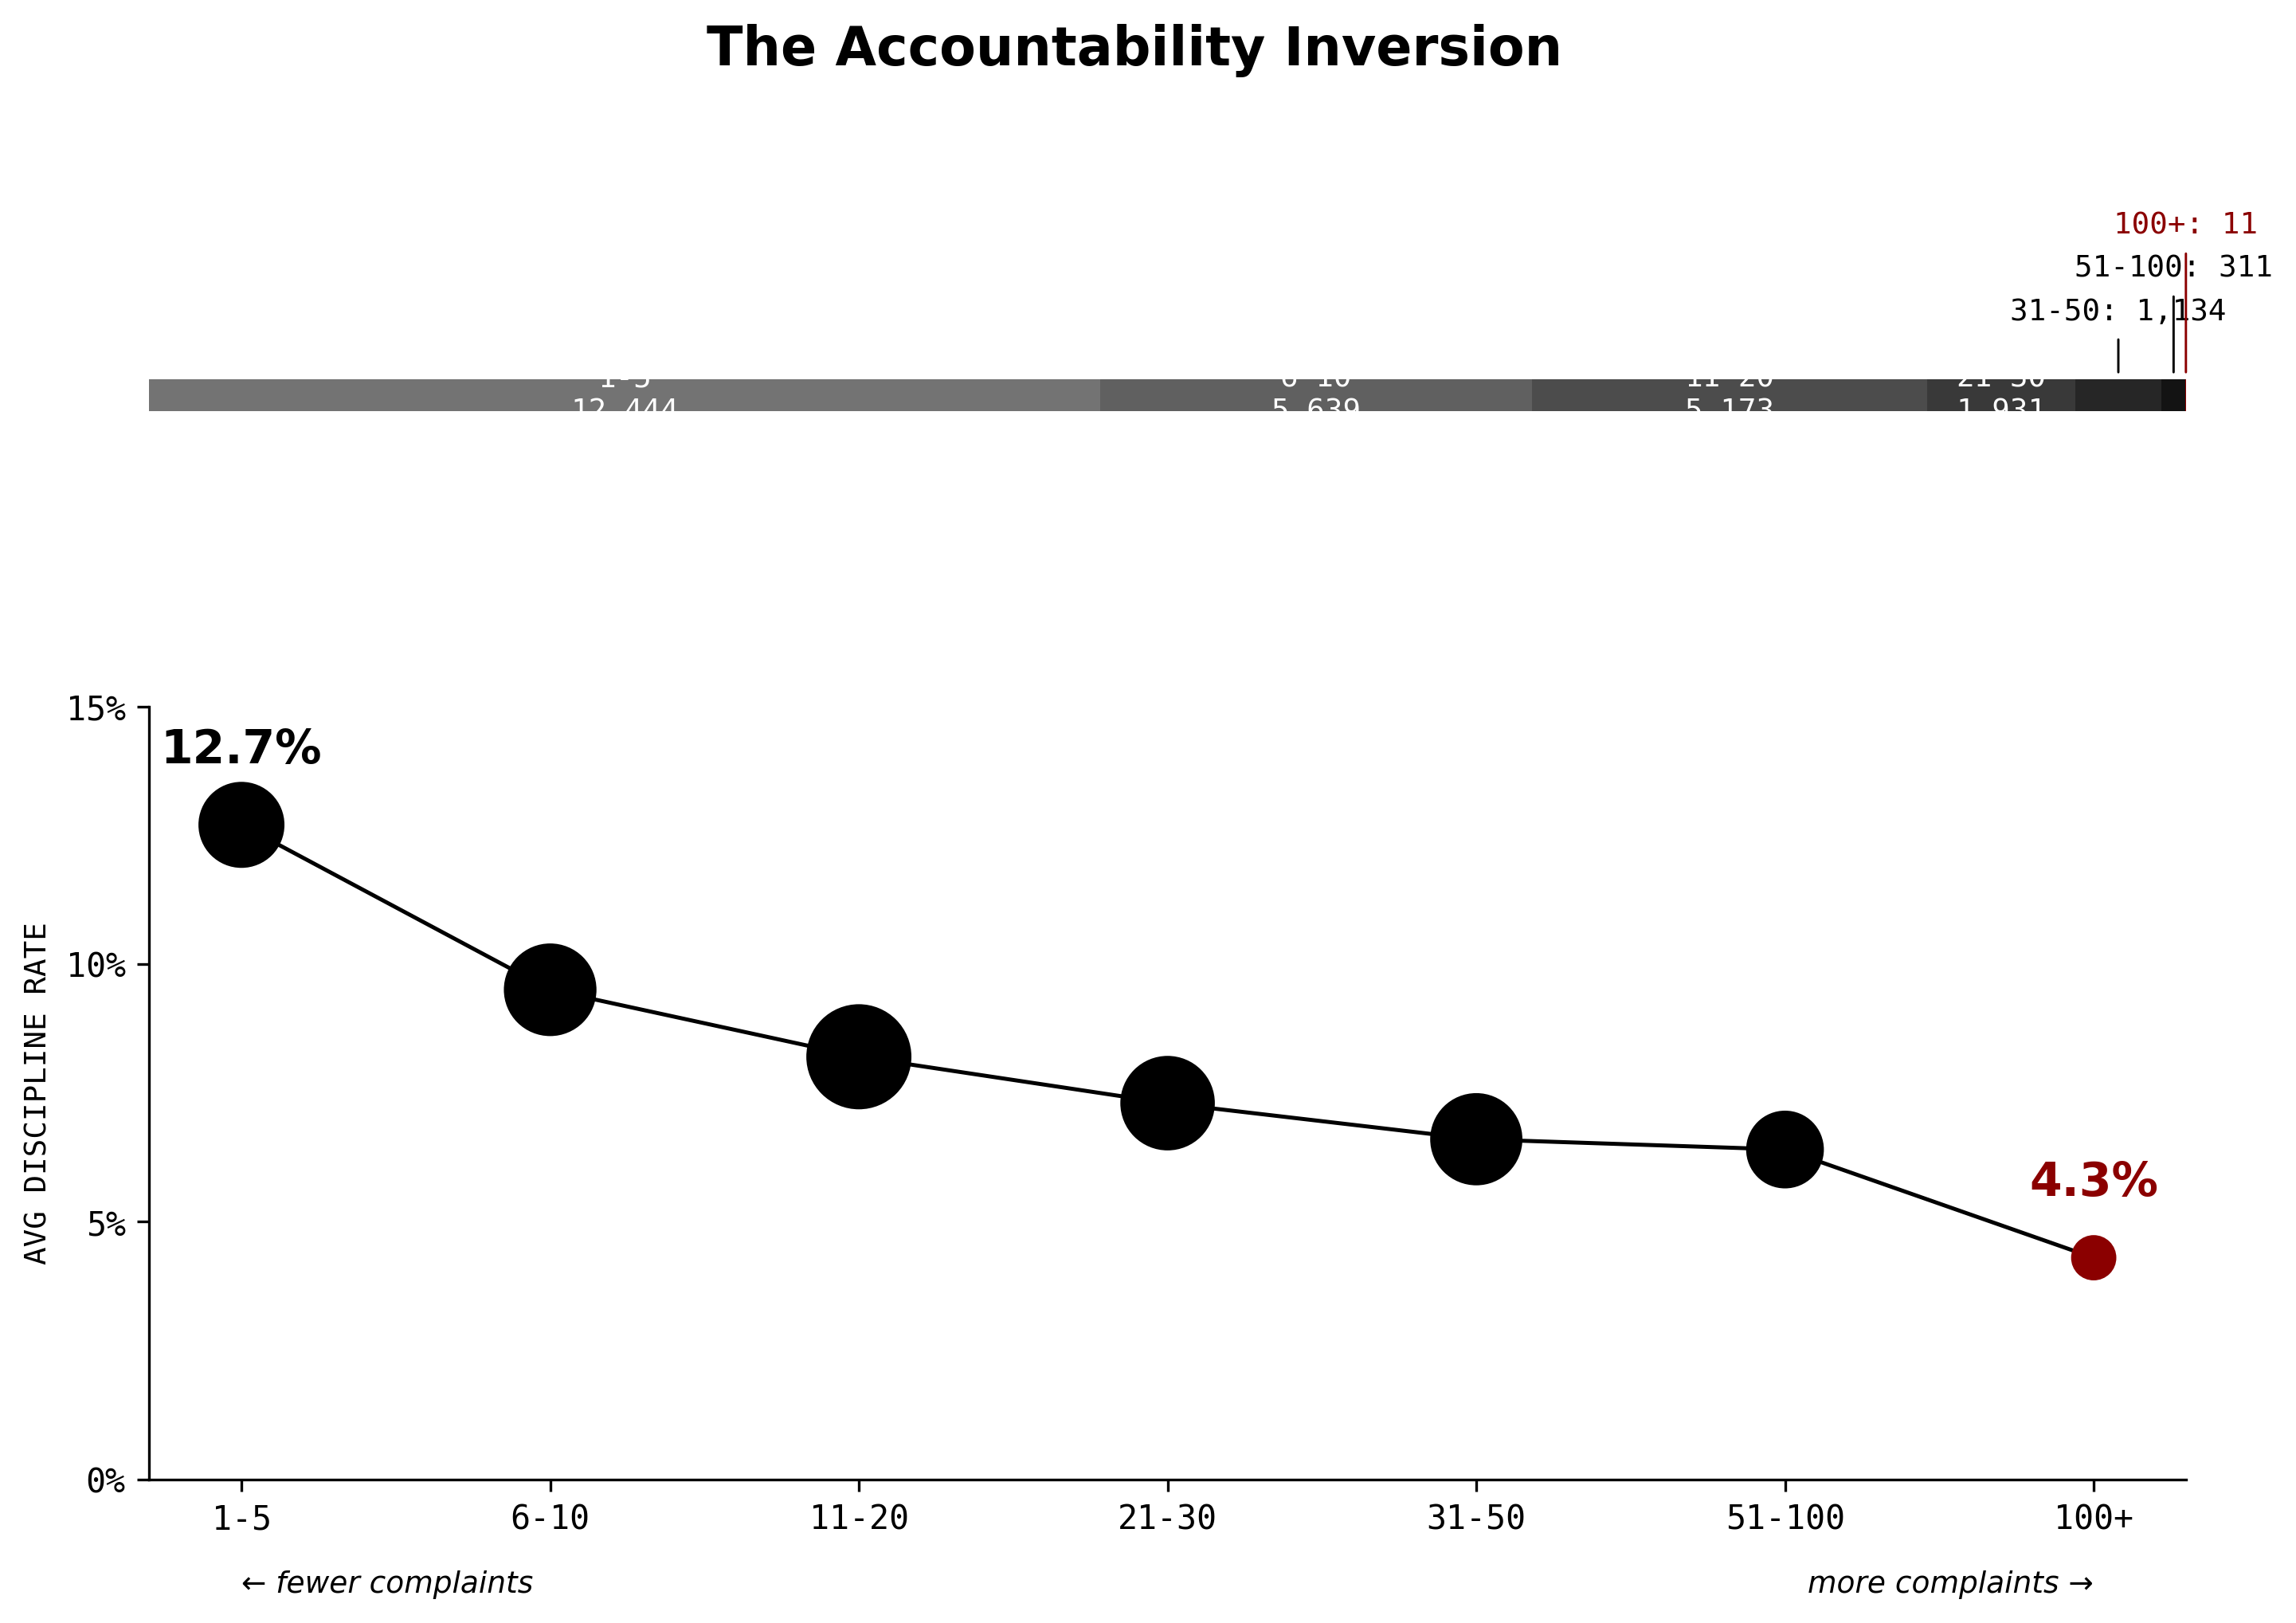